# Desafio 1 - Análise exploratória

In [1]:
import pandas as pd

In [2]:
PATH = r'C:\Users\Usuario\Documents\Estudos\ALURA\05_Data_Science\raw\churn.csv'
dados_brutos = pd.read_csv(PATH)

In [3]:
dados_brutos.head()

,id_cliente,score_credito,pais,sexo_biologico,idade,anos_de_cliente,saldo,servicos_adquiridos,tem_cartao_credito,membro_ativo,salario_estimado,churn
0,15634602,619,França,Mulher,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Espanha,Mulher,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,França,Mulher,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,França,Mulher,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Espanha,Mulher,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# 1 - A primeira etapa em um projeto de Machine Learning é a obtenção de dados. 
# A partir dessa obtenção, podemos fazer a leitura dos dados para se construir um modelo. 
# Como tarefa inicial, faça a leitura da base de dados e verifique a presença de dados nulos. 
# Além disso, remova a coluna 'id_cliente', uma vez que esse tipo de informação única para cada linha não é útil para uso em modelos de machine learning
print(dados_brutos.isnull().sum())
print(dados_brutos.info())

dados_brutos.drop(columns='id_cliente', inplace=True)

id_cliente             0
score_credito          0
pais                   0
sexo_biologico         0
idade                  0
anos_de_cliente        0
saldo                  0
servicos_adquiridos    0
tem_cartao_credito     0
membro_ativo           0
salario_estimado       0
churn                  0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_cliente           10000 non-null  int64  
 1   score_credito        10000 non-null  int64  
 2   pais                 10000 non-null  object 
 3   sexo_biologico       10000 non-null  object 
 4   idade                10000 non-null  int64  
 5   anos_de_cliente      10000 non-null  int64  
 6   saldo                10000 non-null  float64
 7   servicos_adquiridos  10000 non-null  int64  
 8   tem_cartao_credito   10000 non-null  int64  
 9   membro_ativo         100

In [5]:
dados_brutos.columns

Index(['score_credito', 'pais', 'sexo_biologico', 'idade', 'anos_de_cliente',
       'saldo', 'servicos_adquiridos', 'tem_cartao_credito', 'membro_ativo',
       'salario_estimado', 'churn'],
      dtype='object')

In [6]:
# 2 - Após a leitura dos dados, é importante conhecer os dados, checando inconsistências 
# e entendendo o comportamento de cada uma das colunas. 
# Nesta tarefa, faça uma análise exploratória utilizando gráficos para as variáveis categóricas da base de dados, 
# incluindo a variável alvo churn. 
# Para essas variáveis, pode ser utilizado gráficos de barras para fazer a contagem das categorias 
# e fazer um agrupamento por cores de acordo com as categorias da variável alvo.

import plotly.express as px 
px.histogram(dados_brutos, x='pais', color='churn', barmode='group')

In [7]:
px.histogram(dados_brutos, x='sexo_biologico', color='churn', barmode='group')

In [8]:
px.histogram(dados_brutos, x='tem_cartao_credito', color='churn', barmode='group')

In [9]:
px.histogram(dados_brutos, x='membro_ativo', color='churn', barmode='group')

In [10]:
px.histogram(dados_brutos, x='churn')

In [11]:
dados_brutos.head()

,score_credito,pais,sexo_biologico,idade,anos_de_cliente,saldo,servicos_adquiridos,tem_cartao_credito,membro_ativo,salario_estimado,churn
0,619,França,Mulher,42,2,0.00,1,1,1,101348.88,1
1,608,Espanha,Mulher,41,1,83807.86,1,0,1,112542.58,0
2,502,França,Mulher,42,8,159660.80,3,1,0,113931.57,1
3,699,França,Mulher,39,1,0.00,2,0,0,93826.63,0
4,850,Espanha,Mulher,43,2,125510.82,1,1,1,79084.10,0


In [12]:
# 3 - Depois de explorar as variáveis categóricas, chegou a vez das variáveis numéricas. 
# Construa gráficos de distribuição como boxplots ou histogramas para analisar o comportamento dos valores numéricos 
# e checar se existem valores inconsistentes.
px.box(dados_brutos, x='score_credito')


In [13]:
px.box(dados_brutos, x='idade')

In [14]:
px.box(dados_brutos, x='anos_de_cliente')

In [15]:
px.box(dados_brutos, x='salario_estimado', color = 'churn')

In [16]:
px.box(dados_brutos, x = 'saldo', color = 'churn')

In [17]:
px.box(dados_brutos, x = 'servicos_adquiridos', color = 'churn')

# Desafio 2 - Transformação de dados

In [18]:
dados_brutos

,score_credito,pais,sexo_biologico,idade,anos_de_cliente,saldo,servicos_adquiridos,tem_cartao_credito,membro_ativo,salario_estimado,churn
0,619,França,Mulher,42,2,0.00,1,1,1,101348.88,1
1,608,Espanha,Mulher,41,1,83807.86,1,0,1,112542.58,0
2,502,França,Mulher,42,8,159660.80,3,1,0,113931.57,1
3,699,França,Mulher,39,1,0.00,2,0,0,93826.63,0
4,850,Espanha,Mulher,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,França,Homem,39,5,0.00,2,1,0,96270.64,0
9996,516,França,Homem,35,10,57369.61,1,1,1,101699.77,0
9997,709,França,Mulher,36,7,0.00,1,0,1,42085.58,1
9998,772,Alemanha,Homem,42,3,75075.31,2,1,0,92888.52,1


In [19]:
# 1. Para utilizar os dados nos algoritmos de Machine Learning, precisamos informar quais são as variáveis explicativas e qual é a variável alvo. 
# Neste desafio, faça a separação da base de dados de churn entre as variáveis explicativas, armazenando em uma variável x e a variável alvo em y.
X = dados_brutos.drop(columns=('churn'))
y = dados_brutos['churn']

In [20]:
# Variáveis categóricas que estejam em formato de texto não podem ser utilizadas diretamente nos modelos de Machine Learning. 
# Neste desafio, faça a transformação das variáveis categóricas para o formato numérico usando o OneHotEncoder, 
# utilizando o parâmetro drop='if_binary' caso alguma variável tenha apenas 2 categorias.
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
colunas = X.columns

ohe = make_column_transformer((
    OneHotEncoder(drop='if_binary'), 
    ['pais', 'sexo_biologico']
), remainder='passthrough', sparse_threshold=0)

In [21]:
X = ohe.fit_transform(X)
pd.DataFrame(X, columns=ohe.get_feature_names_out(colunas))

,onehotencoder__pais_Alemanha,onehotencoder__pais_Espanha,onehotencoder__pais_França,onehotencoder__sexo_biologico_Mulher,remainder__score_credito,remainder__idade,remainder__anos_de_cliente,remainder__saldo,remainder__servicos_adquiridos,remainder__tem_cartao_credito,remainder__membro_ativo,remainder__salario_estimado
0,0.0,0.0,1.0,1.0,619.0,42.0,2.0,0.00,1.0,1.0,1.0,101348.88
1,0.0,1.0,0.0,1.0,608.0,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58
2,0.0,0.0,1.0,1.0,502.0,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57
3,0.0,0.0,1.0,1.0,699.0,39.0,1.0,0.00,2.0,0.0,0.0,93826.63
4,0.0,1.0,0.0,1.0,850.0,43.0,2.0,125510.82,1.0,1.0,1.0,79084.10
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.0,0.0,1.0,0.0,771.0,39.0,5.0,0.00,2.0,1.0,0.0,96270.64
9996,0.0,0.0,1.0,0.0,516.0,35.0,10.0,57369.61,1.0,1.0,1.0,101699.77
9997,0.0,0.0,1.0,1.0,709.0,36.0,7.0,0.00,1.0,0.0,1.0,42085.58
9998,1.0,0.0,0.0,0.0,772.0,42.0,3.0,75075.31,2.0,1.0,0.0,92888.52


In [22]:
# 3. A variável alvo, como é do tipo categórica, também precisa passar por um tratamento similar às variáveis explicativas categóricas 
# para que possa ser usada nos algoritmos. Nessa tarefa, utilize o método LabelEncoder para fazer a transformação da variável churn.
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)
y

array([1, 0, 1, ..., 1, 1, 0], shape=(10000,))

# Desafio 3 - Ajustando modelos

In [23]:
#A separação dos dados entre conjunto de treinamento e teste é essencial para compreender se um modelo está conseguindo aprender os padrões 
# e generalizar para novos dados. Nesta tarefa, faça a divisão da base de dados entre treinamento e teste de forma estratificada.
from sklearn.model_selection import train_test_split
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, stratify=y, random_state=10)

In [25]:
# Um modelo de base é muito importante para definir um critério de comparação para modelos mais complexos. 
# Nesta etapa, crie um modelo de base com o DummyClassifier e encontre a taxa de acerto com o método score.
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier()
dummy.fit(X_treino, y_treino)
dummy.score(X_teste, y_teste)

0.7964

0.852


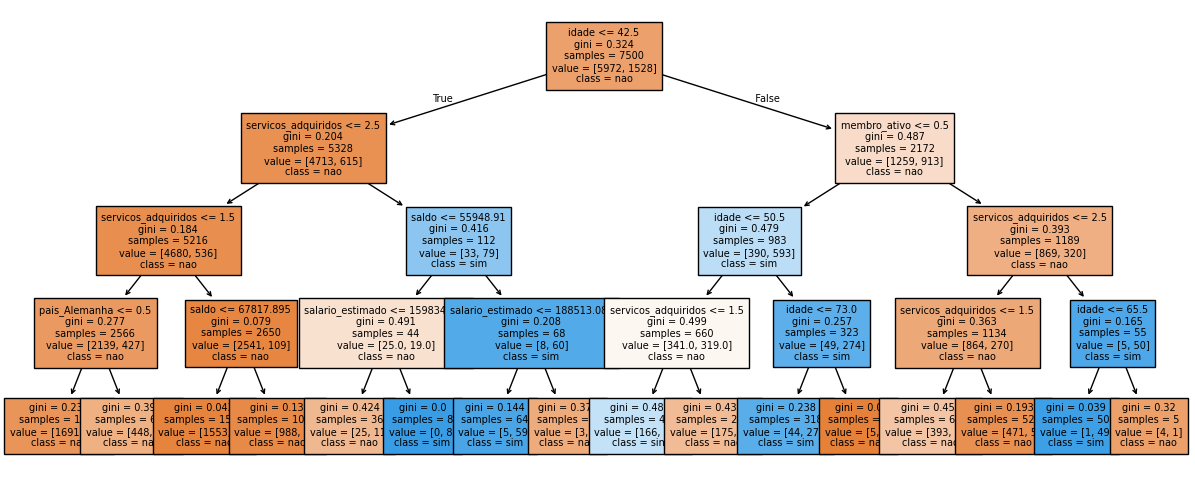

In [32]:
# A árvore de decisão é um algoritmo que faz as classificações a partir de decisões simples tomadas a partir dos dados. 
# Temos que tomar certo cuidado para não utilizar uma profundidade muito grande, 
# porque isso pode provocar um sobreajuste do modelo aos dados de treinamento. 
# Neste desafio, crie um modelo de árvore de decisão com o parâmetro max_depth=4, avalie o desempenho do modelo nos dados de teste 
# e visualize as decisões da árvore usando o método plot_tree
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(max_depth=4, random_state=10)
dtc.fit(X_treino, y_treino)
print(dtc.score(X_teste, y_teste))

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
colunas = [
    'pais_Alemanha', 
    'pais_Espanha', 
    'pais_França', 
    'sexo_biologico', 
    'score_credito', 
    'idade', 
    'anos_de_cliente', 
    'saldo', 
    'servicos_adquiridos', 
    'tem_cartao_credito', 
    'membro_ativo', 
    'salario_estimado']

plt.figure(figsize=(15,6))
plot_tree(dtc, filled=True, class_names=['nao', 'sim'], fontsize=7, feature_names=colunas);

# Desafio 4 - Seleção de Modelos

In [ ]:
# A normalização de dados é uma tarefa importante para manter todos os valores numéricos em uma mesma escala e garantir que todas as características 
# tenham o mesmo impacto no modelo. Nesta tarefa, faça a normalização da base de dados usando o MinMaxScaler.
from sklearn.preprocessing import MinMaxScaler
normalizacao = MinMaxScaler()
X_treino_normalizado = normalizacao.fit_transform(X_treino)
pd.DataFrame(X_treino_normalizado)

array([[0.        , 0.        , 1.        , ..., 1.        , 1.        ,
        0.40857297],
       [1.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.89678719],
       [1.        , 0.        , 0.        , ..., 1.        , 0.        ,
        0.91550888],
       ...,
       [1.        , 0.        , 0.        , ..., 1.        , 0.        ,
        0.2251702 ],
       [0.        , 0.        , 1.        , ..., 1.        , 1.        ,
        0.87488385],
       [0.        , 0.        , 1.        , ..., 0.        , 0.        ,
        0.88206209]], shape=(7500, 12))

In [ ]:
# Com os dados normalizados, podemos utilizar o modelo KNN, que faz cálculos de distância para encontrar os vizinhos mais próximos. 
# Nesta atividade, crie um modelo KNN usando o KNeighborsClassifier com os dados normalizados e avalie o desempenho nos dados de teste, também normalizados.
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_treino_normalizado, y_treino)

X_teste_normalizado = normalizacao.transform(X_teste)
knn.score(X_teste_normalizado, y_teste)

0.8136

In [37]:
# Após a construção dos modelos, é o momento de comparar os resultados e selecionar aquele que tem o melhor desempenho. 
# Neste desafio, avalie a taxa de acerto dos modelos DummyClassifier, DecisionTreeClassifier e KNeighborsClassifier 
# que foram construídos nos outros desafios utilizando o método score e, em seguida, 
# armazene o modelo com melhor acurácia em um arquivo pickle. Os modelos de transformação também precisam ser armazenados, 
# que é o caso do OneHotEncoder e do MinMaxScaler, caso o KNN tenha o melhor desempenho.
print(f'Acurácia Dummy: {dummy.score(X_teste, y_teste)}')
print(f'Acurácia Árvore: {dtc.score(X_teste, y_teste)}')
print(f'Acurácia KNN: {knn.score(X_teste_normalizado, y_teste)}')

Acurácia Dummy: 0.7964
Acurácia Árvore: 0.852
Acurácia KNN: 0.8136


In [38]:
import pickle
with open('modelo_onehotenc.pkl', 'wb') as file: 
    pickle.dump(ohe, file)

with open('modelo_arvore.pkl', 'wb') as file: 
    pickle.dump(dtc, file)

In [39]:
# Depois que o modelo está em produção, já pode ser utilizado para classificar novos dados. 
# Neste desafio, faça a leitura dos arquivos pickle dos modelos que foram salvos no desafio anterior 
# e utilize os modelos para fazer a predição do seguinte registro:
novo_dado = pd.DataFrame({
    'score_credito': [850],
    'pais':['França'],
    'sexo_biologico':['Homem'],
    'idade': [27],
    'anos_de_cliente': [3],
    'saldo': [56000],
    'servicos_adquiridos': [1],
    'tem_cartao_credito': [1],
    'membro_ativo': [1],
    'salario_estimado': [85270.00]
})

novo_dado = pd.DataFrame(novo_dado)

modelo_one_hot = pd.read_pickle(r'C:\Users\Usuario\Documents\Estudos\ALURA\05_Data_Science\03_ml_classificacao\modelo_onehotenc.pkl')
modelo_arvore = pd.read_pickle(r'C:\Users\Usuario\Documents\Estudos\ALURA\05_Data_Science\03_ml_classificacao\modelo_arvore.pkl')

novo_dado = modelo_one_hot.transform(novo_dado)
modelo_arvore.predict(novo_dado)

array([0])